# Credit Card Clustering

**Problem Statement:**

> You are given a data for credit card company. Explore the data and find clusters so the company can perform targeted marketing, customer retention, and risk management decisions.

In [1]:
import pandas as pd
import numpy as np

# imports
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("data_CC_General.csv")
# df = pd.read_csv("https://raw.githubusercontent.com/ash322ash422/data/refs/heads/main/data_CC_GENERAL.csv")


df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [80]:
# View the first 5 rows
print(df.head())

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

In [81]:
# Shape of the dataset
print("Shape:", df.shape)

Shape: (8950, 18)


In [82]:
# 1) Check data type, memory consumption, etc
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [83]:
# 2) Downcast float columns
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].apply(
    pd.to_numeric,
    downcast='float'
)

# Downcast integer columns
int_cols = df.select_dtypes(include=['int64']).columns
df[int_cols] = df[int_cols].apply(
    pd.to_numeric,
    downcast='integer'
)

# Memory usage after downcasting
print("\nMemory after:")
print(df.info(memory_usage='deep'))


Memory after:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float32
 2   BALANCE_FREQUENCY                 8950 non-null   float32
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float32
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float32
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float32
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float32
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float32
 11  CASH_ADVANCE_TRX                  8950 non-null   int8

In [84]:
# How much memory saved ? 29%
(1.7-1.2)/1.7

0.29411764705882354

In [85]:
# Summary statistics
print(df.describe())

            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8950.000000        8950.000000   8950.000000       8950.000000   
mean    1564.474854           0.877271   1003.204834        592.437371   
std     2081.531982           0.236904   2136.634782       1659.887917   
min        0.000000           0.000000      0.000000          0.000000   
25%      128.281921           0.888889     39.635000          0.000000   
50%      873.385254           1.000000    361.280000         38.000000   
75%     2054.140015           1.000000   1110.130000        577.405000   
max    19043.138672           1.000000  49039.570000      40761.250000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             8950.000000   8950.000000          8950.000000   
mean               411.067657    978.871112             0.490351   
std                904.338135   2097.163877             0.401371   
min                  0.000000      0.000000             0.000

# Missing values

In [86]:
# 1) Check missing values before imputation
print("Missing values before:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


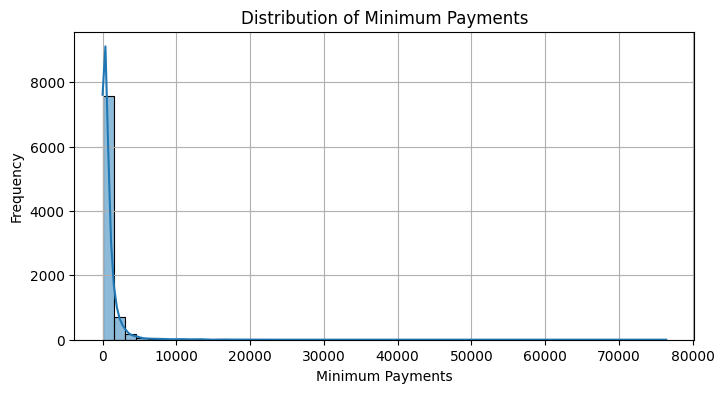

In [87]:
# 2) Distribution of MINIMUM_PAYMENTS
plt.figure(figsize=(8, 4))
sns.histplot(df['MINIMUM_PAYMENTS'].dropna(), bins=50, kde=True)

plt.title('Distribution of Minimum Payments')
plt.xlabel('Minimum Payments')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

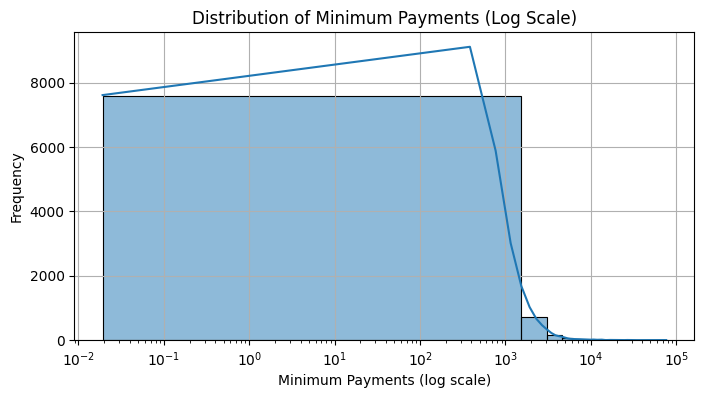

In [88]:
# 3) Lets look at the log scale
plt.figure(figsize=(8, 4))
sns.histplot(df['MINIMUM_PAYMENTS'].dropna(), bins=50, kde=True)

plt.xscale('log')
plt.title('Distribution of Minimum Payments (Log Scale)')
plt.xlabel('Minimum Payments (log scale)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [89]:
# 4) Fill missing values with column medians because it is right skewed
df = df.fillna(df.median(numeric_only=True))

# Check missing values after imputation
print("\nMissing values after:")
print(df.isnull().sum().sum())


Missing values after:
0


# Extract relevant features
- I choose to work with only 4 features for now.
- Exercise: Add more later

In [90]:
features = [
    'PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS'
]

X = df[features]
X

,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,95.40,0.000000,1000.0,201.802084
1,0.00,6442.945483,7000.0,4103.032597
2,773.17,0.000000,7500.0,622.066742
3,1499.00,205.788017,7500.0,0.000000
4,16.00,0.000000,1200.0,678.334763
...,...,...,...,...
8945,291.12,0.000000,1000.0,325.594462
8946,300.00,0.000000,1000.0,275.861322
8947,144.40,0.000000,1000.0,81.270775
8948,0.00,36.558778,500.0,52.549959


# Standardize the features using StandardScaler

In [91]:
# 1) 
# from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit and transform the feature matrix
X_scaled = scaler.fit_transform(X)

# Check shape
print(X_scaled.shape)

(8950, 4)


In [92]:
# 2) View first 5 standardized rows

print("X:\n", X[:5])
print("X_scaled:\n", X_scaled[:5])
print("-------------------\n")

print(f"{X.loc[0].tolist()} --> {X_scaled[0]}")
print(f"{X.loc[1].tolist()} --> {X_scaled[1]}")

X:
    PURCHASES  CASH_ADVANCE  CREDIT_LIMIT     PAYMENTS
0      95.40      0.000000        1000.0   201.802084
1       0.00   6442.945483        7000.0  4103.032597
2     773.17      0.000000        7500.0   622.066742
3    1499.00    205.788017        7500.0     0.000000
4      16.00      0.000000        1200.0   678.334763
X_scaled:
 [[-0.42489974 -0.46678555 -0.9603784  -0.52897879]
 [-0.46955188  2.60560451  0.68867844  0.81864213]
 [-0.10766823 -0.46678555  0.82609984 -0.38380474]
 [ 0.23205785 -0.36865325  0.82609984 -0.59868826]
 [-0.46206305 -0.46678555 -0.90540984 -0.3643678 ]]
-------------------

[95.4, 0.0, 1000.0, 201.802084] --> [-0.42489974 -0.46678555 -0.9603784  -0.52897879]
[0.0, 6442.945483, 7000.0, 4103.032597] --> [-0.46955188  2.60560451  0.68867844  0.81864213]


In [93]:
# 3) Optional Verification

print(X_scaled.mean(axis=0))   # close to 0
print(X_scaled.std(axis=0))    # close to 1

[ 3.17560999e-18 -6.35121998e-18  1.01619520e-16 -2.54048799e-17]
[1. 1. 1. 1.]


In [94]:
# 4) Optional: Convert Back to a DataFrame

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=df.index
)

print(X_scaled.head())

   PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS
0  -0.424900     -0.466786     -0.960378 -0.528979
1  -0.469552      2.605605      0.688678  0.818642
2  -0.107668     -0.466786      0.826100 -0.383805
3   0.232058     -0.368653      0.826100 -0.598688
4  -0.462063     -0.466786     -0.905410 -0.364368


## Use the Elbow Method to Choose the Optimal Number of Clusters (`k`)

The Elbow Method helps determine a reasonable number of clusters for K-Means.

---

## Key Idea

K-Means minimizes the **within-cluster sum of squares (WCSS)**, also called **inertia**.

As the number of clusters increases:

* WCSS always decreases.
* The improvement becomes smaller after a certain point.

The “elbow” in the curve suggests a good choice for `k`.

---

## What K-Means Minimizes
$$WCSS = \sum_{k=1}^{K} \sum_{x_i \in C_k} ||x_i - \mu_k||^2$$

Where:
* $C_k$ is cluster $k$
* $\mu_k$ is the centroid of cluster $k$
* $x_i$ is a data point

---


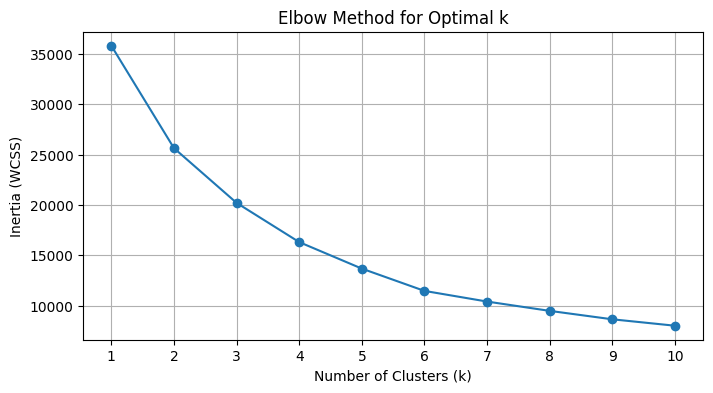

In [95]:
## Code for the Elbow Method

# Store inertia values
inertia = []

# Try different values of k
K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.xticks(K)
plt.grid(True)
plt.show()


## How to Interpret the Plot

Look for the point where the curve changes from steep to relatively flat.


> “We keep adding clusters until the improvement becomes marginal. The elbow marks a good trade-off between simplicity and fit.”


For this credit card dataset, `k = 4` is a strong and interpretable starting point.

# Fit K-Means and assign each customer to a cluster

In [96]:
from sklearn.cluster import KMeans

# Choose number of clusters
k = 4

# Create and fit the model
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# Fit the model and get cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)

# Add labels to the original DataFrame
df['cluster'] = cluster_labels

# Display the first few rows
print(df[features + ['cluster']].head())

   PURCHASES  CASH_ADVANCE  CREDIT_LIMIT     PAYMENTS  cluster
0      95.40      0.000000        1000.0   201.802084        1
1       0.00   6442.945483        7000.0  4103.032597        3
2     773.17      0.000000        7500.0   622.066742        0
3    1499.00    205.788017        7500.0     0.000000        0
4      16.00      0.000000        1200.0   678.334763        1


In [97]:
# The learned centroids in standardized units:
print(kmeans.cluster_centers_)

[[ 0.44401845 -0.07318591  1.13147487  0.24470044]
 [-0.23682288 -0.21600776 -0.52347544 -0.29133829]
 [ 6.99277423  0.0570996   2.33120776  5.43350169]
 [-0.14751876  3.02406451  1.1347291   1.67771103]]


In [98]:
# Number of Customers in Each Cluster
print(df['cluster'].value_counts().sort_index())

cluster
0    2196
1    6181
2      80
3     493
Name: count, dtype: int64


# Profile and Interpret Each Cluster

In [99]:
# 1) Average values for each cluster
cluster_profile = (
    df
    .groupby('cluster')[features]
    .mean()
    .round(2)
)

print(cluster_profile)

         PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS
cluster                                                 
0          1954.32        824.53   8614.139648   2443.06
1           497.06        526.34   2591.479980    889.96
2         15943.37       1098.61  12976.250000  17462.60
3           688.03       7320.48   8622.929688   6589.95


In [100]:
# 2)
cluster_sizes = df['cluster'].value_counts().sort_index()

cluster_profile['num_customers'] = cluster_sizes
cluster_profile

,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,num_customers
cluster,,,,,
0,1954.32,824.53,8614.139648,2443.06,2196
1,497.06,526.34,2591.479980,889.96,6181
2,15943.37,1098.61,12976.250000,17462.60,80
3,688.03,7320.48,8622.929688,6589.95,493


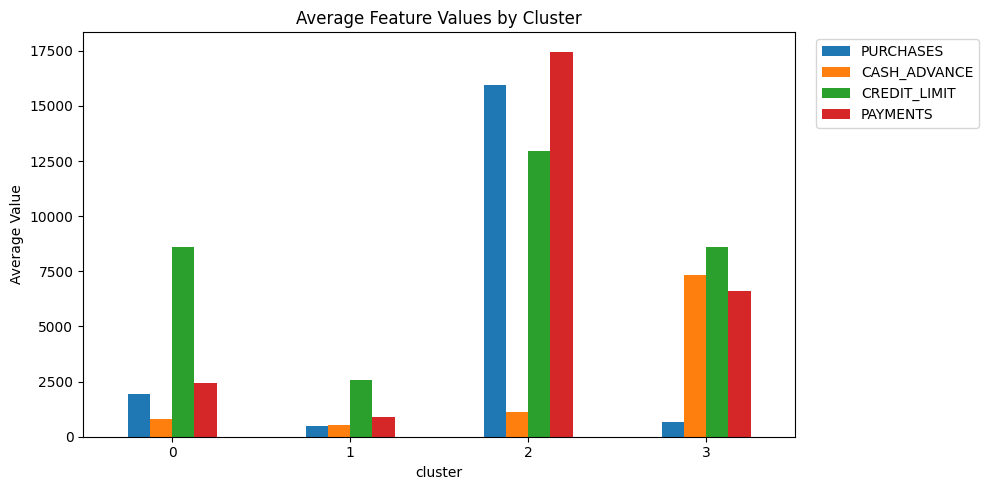

In [101]:
# 3) Plot it
cluster_profile[features].plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Average Feature Values by Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Interpretation:

## Cluster 0 — Active Customers
These customers:
```
Spend regularly.
Occasionally use cash advances.
Have relatively high credit limits.
Make healthy payments.

```

Business Meaning: These are solid, profitable customers who use the card actively but not excessively.

Suggested Segment Name: **Active Customers**


## Cluster 1 — Low Activity Customers
These customers:
```
Spend little.
Have lower credit limits.
Make smaller payments.
```

Business Meaning: These are occasional users or dormant customers.

Suggested Segment Name: Low Activity Customers



## Cluster 2 — Premium / VIP Customers
These customers:
```
Spend extremely heavily.
Have the highest credit limits.
Make very large payments.
```

Business Meaning: These are elite, highly valuable customers.

Suggested Segment Name: Premium / VIP Customers


## Cluster 3 — Cash Advance Heavy Customers
These customers:
```
Make relatively few purchases.
Rely heavily on cash advances.
Make large payments.
```
Business Meaning: These customers may be using the credit card as a short-term borrowing tool rather than for purchases. This behavior can be associated with higher financial stress or elevated credit risk.

Suggested Segment Name: Cash Advance Heavy Users

## Business Insights
### Largest Segment

Cluster 1 contains 6,181 customers (~69% of the dataset), indicating most customers are low activity users.

### Most Valuable Segment

Cluster 2 contains only 80 customers (<1%) but generates very high spending and payments.

### Potential Risk Segment

Cluster 3 shows unusually high cash advance usage and may warrant closer monitoring.

### Core Revenue Segment

Cluster 0 represents a large group of healthy, engaged customers.

---

### Suggested Marketing Actions


| Segment            | Recommended Action                                    |
| ------------------ | ----------------------------------------------------- |
| Premium / VIP      | Concierge benefits, premium rewards, retention offers |
| Active Customers   | Cross-sell and loyalty programs                       |
| Low Activity       | Activation campaigns and usage incentives             |
| Cash Advance Heavy | Risk monitoring and financial wellness offers         |


---

This segmentation can support **targeted marketing, customer retention, and risk management decisions.**

In [102]:
cluster_names = {
    0: "Active Customers",
    1: "Low Activity Customers",
    2: "Premium VIP Customers",
    3: "Cash Advance Heavy Users"
}

df['segment'] = df['cluster'].map(cluster_names)
df.sample(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster,segment
5662,C15820,3842.454834,1.0,0.00,0.00,0.000000,6381.534619,0.000000,0.000000,0.000000,0.500000,24,0,6500.0,3869.748950,1742.491124,0.083333,12,3,Cash Advance Heavy Users
5286,C15435,288.097290,1.0,2622.60,0.00,2622.600098,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,450.0,2718.479540,2413.233231,0.833333,12,1,Low Activity Customers
6746,C16934,1250.526855,1.0,2576.81,2576.81,0.000000,599.535996,0.583333,0.583333,0.000000,0.166667,2,34,3750.0,3811.567017,3536.319962,0.090909,12,1,Low Activity Customers
2575,C12650,1072.257446,1.0,0.00,0.00,0.000000,39.265903,0.000000,0.000000,0.000000,0.083333,1,0,1200.0,286.462960,263.950897,0.000000,12,1,Low Activity Customers
4632,C14758,4768.062500,1.0,374.81,333.20,41.610001,9917.639168,0.333333,0.250000,0.083333,0.833333,18,4,7000.0,5283.297064,1589.293892,0.000000,12,3,Cash Advance Heavy Users
4571,C14697,2819.630615,1.0,0.00,0.00,0.000000,230.543537,0.000000,0.000000,0.000000,0.250000,7,0,3000.0,810.389383,1147.376672,0.000000,12,1,Low Activity Customers
4081,C14197,438.429108,1.0,5044.36,3015.56,2028.800049,0.000000,1.000000,0.416667,0.916667,0.000000,0,35,5500.0,4591.418823,186.284070,1.000000,12,0,Active Customers
8221,C18441,11.391553,1.0,201.52,0.00,201.520004,0.000000,0.916667,0.000000,0.916667,0.000000,0,11,4000.0,210.443741,71.701127,0.900000,12,1,Low Activity Customers
1345,C11390,5608.513672,1.0,0.00,0.00,0.000000,4362.927953,0.000000,0.000000,0.000000,0.166667,5,0,11000.0,1648.391392,1222.355238,0.000000,12,0,Active Customers
3943,C14054,14.442528,1.0,163.90,0.00,163.899994,0.000000,1.000000,0.000000,0.909091,0.000000,0,11,1500.0,138.776431,152.468146,0.777778,11,1,Low Activity Customers
